In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rust_pathsim
from mc_option_pricing.pricing import price_european_call
from mc_option_pricing.black_scholes import black_scholes_call

In [2]:
# Parameters for the option and simulation
PARAMS = dict(
    start    = 100.0,
    strike   = 100.0,
    risk_free= 0.05,
    sigma    = 0.2,
    maturity = 1.0,
)
N_PATHS = 1_000 
STEPS   = 252     

In [3]:
def simulate_full_paths(params, n_paths, steps, seed=42):
    """Simulate full paths of the underlying asset price using geometric Brownian motion."""
    dt = params['maturity'] / steps
    
    # Initialize array to hold all paths
    paths = np.zeros((n_paths, steps + 1))
    paths[:, 0] = params['start']  # Start price for all paths
    
    # Random shocks for all paths and steps at once
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal((n_paths, steps))
    
    # GBM step by step
    drift     = (params['risk_free'] - 0.5 * params['sigma']**2) * dt
    diffusion = params['sigma'] * np.sqrt(dt)
    
    for t in range(steps):
        paths[:, t+1] = paths[:, t] * np.exp(drift + diffusion * Z[:, t])
    
    return paths

paths = simulate_full_paths(PARAMS, N_PATHS, STEPS)
print(f"Simulated paths: {paths.shape}")  # (1000, 253)

Simulated paths: (1000, 253)


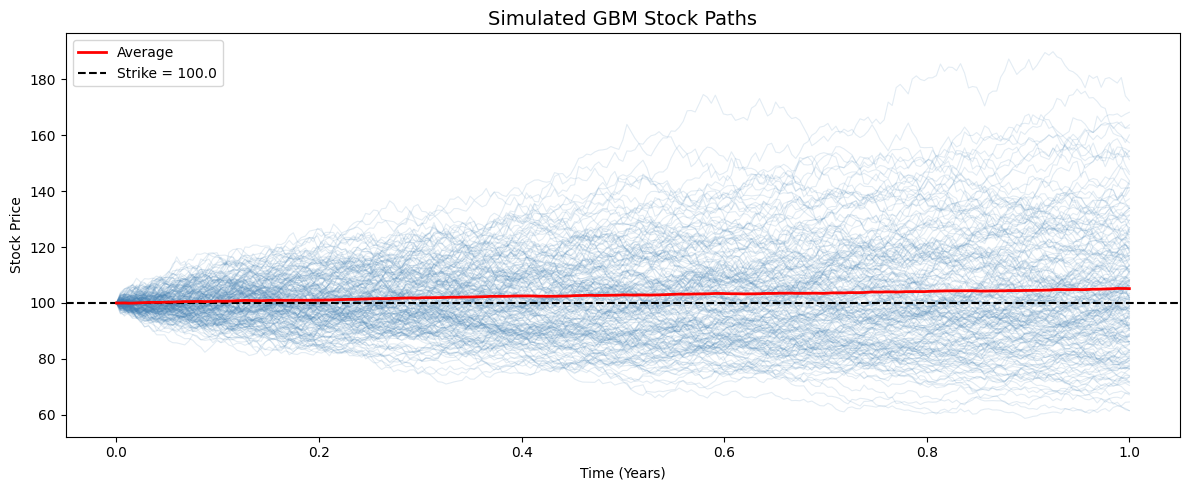

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))

time_axis = np.linspace(0, PARAMS['maturity'], STEPS + 1)

# Plotting a subset of paths for clarity
for i in range(200):
    ax.plot(time_axis, paths[i], alpha=0.15, linewidth=0.8, color='steelblue')

# Highlight the average path
ax.plot(time_axis, paths.mean(axis=0), color='red',
        linewidth=2, label='Average', zorder=5)

# Strike line
ax.axhline(PARAMS['strike'], color='black', linestyle='--',
           linewidth=1.5, label=f"Strike = {PARAMS['strike']}")

ax.set_title('Simulated GBM Stock Paths', fontsize=14)
ax.set_xlabel('Time (Years)')
ax.set_ylabel('Stock Price')
ax.legend()
plt.tight_layout()
plt.show()

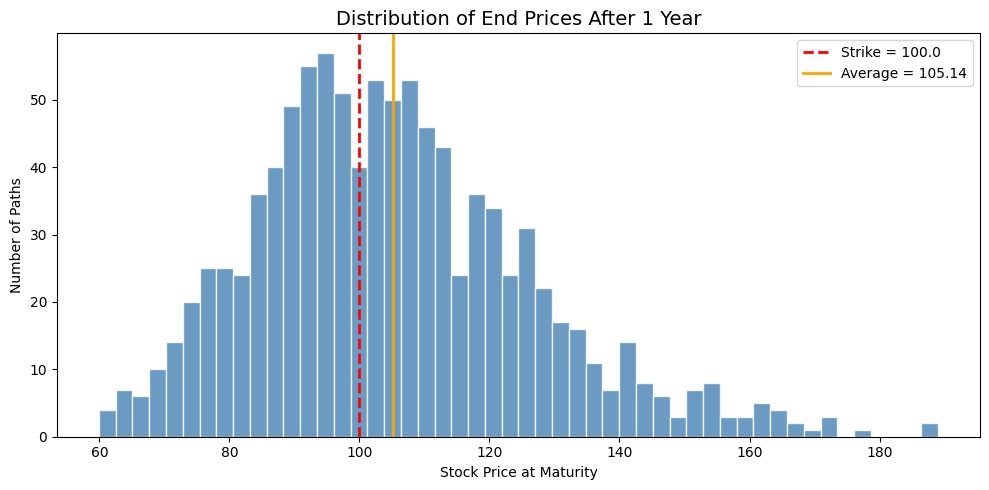

In [5]:
end_prices = paths[:, -1]  # End prices at maturity

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(end_prices, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(PARAMS['strike'], color='red', linestyle='--',
           linewidth=2, label=f"Strike = {PARAMS['strike']}")
ax.axvline(end_prices.mean(), color='orange', linestyle='-',
           linewidth=2, label=f"Average = {end_prices.mean():.2f}")

ax.set_title('Distribution of End Prices After 1 Year', fontsize=14)
ax.set_xlabel('Stock Price at Maturity')
ax.set_ylabel('Number of Paths')
ax.legend()
plt.tight_layout()
plt.show()

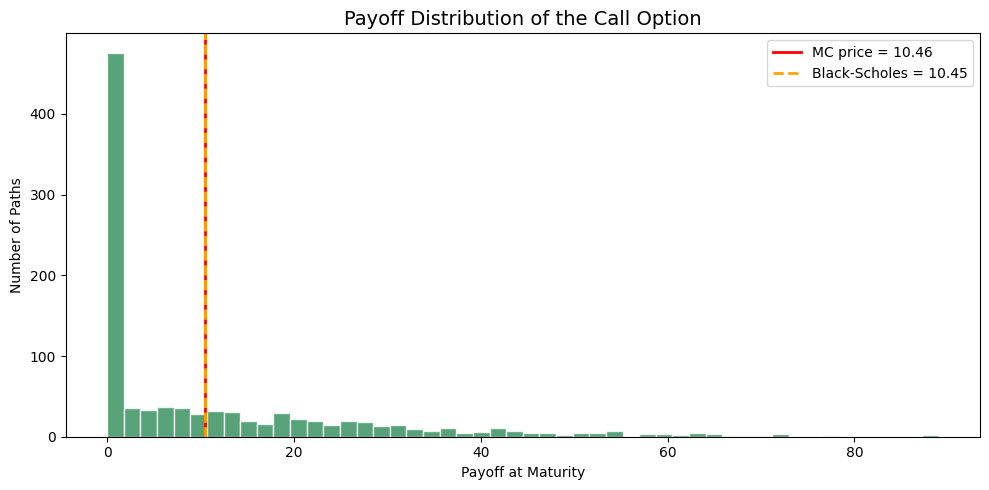

In [6]:
payoffs = np.maximum(end_prices - PARAMS['strike'], 0)

mc_result = price_european_call(**PARAMS, n=100_000)
bs_price  = black_scholes_call(**PARAMS)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(payoffs, bins=50, color='seagreen', edgecolor='white', alpha=0.8)
ax.axvline(mc_result['price'], color='red', linewidth=2,
           label=f"MC price = {mc_result['price']:.2f}")
ax.axvline(bs_price, color='orange', linewidth=2, linestyle='--',
           label=f"Black-Scholes = {bs_price:.2f}")

ax.set_title('Payoff Distribution of the Call Option', fontsize=14)
ax.set_xlabel('Payoff at Maturity')
ax.set_ylabel('Number of Paths')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
from mc_option_pricing.greeks import delta, gamma
from mc_option_pricing.black_scholes import black_scholes_delta, black_scholes_gamma

PARAMS = dict(start=100, strike=100, risk_free=0.05, sigma=0.2, maturity=1.0)

mc_delta = delta(**PARAMS)
mc_gamma = gamma(**PARAMS)
bs_delta = black_scholes_delta(**PARAMS)
bs_gamma = black_scholes_gamma(**PARAMS)

print(f"{'':20} {'Monte Carlo':>12} {'Black-Scholes':>14}")
print(f"{'-'*48}")
print(f"{'Delta':20} {mc_delta:>12.4f} {bs_delta:>14.4f}")
print(f"{'Gamma':20} {mc_gamma:>12.4f} {bs_gamma:>14.4f}")

                      Monte Carlo  Black-Scholes
------------------------------------------------
Delta                      0.6361         0.6368
Gamma                      0.0189         0.0188


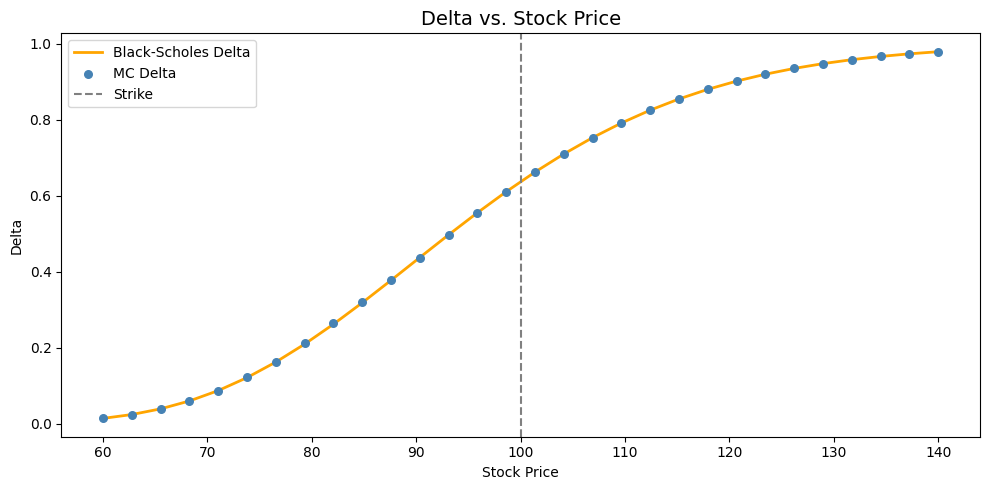

In [8]:
spots = np.linspace(60, 140, 30)

mc_deltas = [delta(s, **{k: v for k, v in PARAMS.items() if k != 'start'}) for s in spots]
bs_deltas = [black_scholes_delta(s, **{k: v for k, v in PARAMS.items() if k != 'start'}) for s in spots]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(spots, bs_deltas, color='orange', linewidth=2, label='Black-Scholes Delta')
ax.scatter(spots, mc_deltas, color='steelblue', s=30, label='MC Delta', zorder=5)
ax.axvline(PARAMS['strike'], color='gray', linestyle='--', label='Strike')
ax.set_title('Delta vs. Stock Price', fontsize=14)
ax.set_xlabel('Stock Price')
ax.set_ylabel('Delta')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
import time
import rust_pathsim
from mc_option_pricing.python_sim import python_pathsim

# Parameter
bench_params = dict(
    start=100.0, ex_yield=0.05, sigma=0.2,
    dt=1/252, steps=252, seed=42,
)
N_PATHS = 50_000

# Python measurement
start_time = time.perf_counter()
python_pathsim(**bench_params, n=N_PATHS)
python_time = time.perf_counter() - start_time

# Rust measurement
start_time = time.perf_counter()
rust_pathsim.rust_simulation(**bench_params, n=N_PATHS)
rust_time = time.perf_counter() - start_time

speedup = python_time / rust_time

print(f"{'Python:':10} {python_time:.3f}s")
print(f"{'Rust:':10} {rust_time:.3f}s")
print(f"{'Speedup:':10} {speedup:.1f}x faster")

Python:    6.093s
Rust:      0.365s
Speedup:   16.7x faster


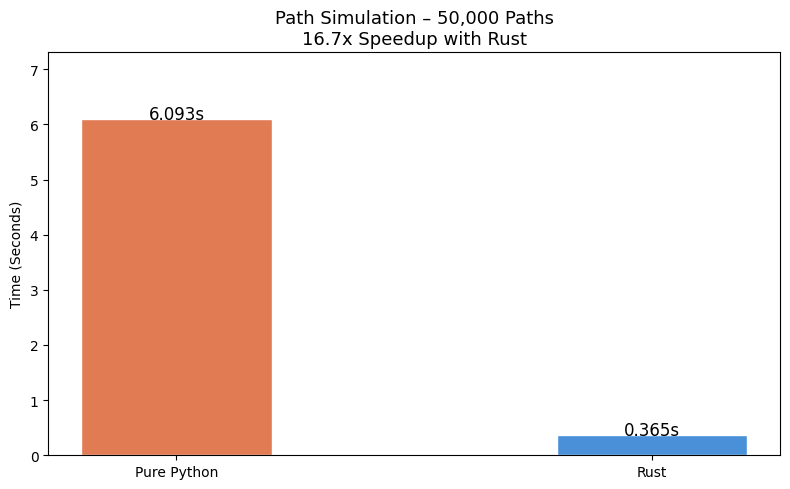

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    ['Pure Python', 'Rust'],
    [python_time, rust_time],
    color=['#e07b54', '#4a90d9'],
    width=0.4,
    edgecolor='white',
)

# Times as labels above the bars
for bar, t in zip(bars, [python_time, rust_time]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{t:.3f}s",
        ha='center', fontsize=12
    )

ax.set_title(f'Path Simulation – {N_PATHS:,} Paths\n{speedup:.1f}x Speedup with Rust',
             fontsize=13)
ax.set_ylabel('Time (Seconds)')
ax.set_ylim(0, python_time * 1.2)
plt.tight_layout()
plt.show()